## Tooth Segmentation Using YOLO11


In [1]:
!nvidia-smi

Wed Dec  3 02:42:54 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLOv11

**NOTE:** Currently, YOLOv10 does not have its own PyPI package. Therefore, we need to install the code from the source.

In [3]:
%pip install ultralytics supervision roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (8 CPUs, 51.0 GB RAM, 38.3/235.7 GB disk)


**NOTE:** We will also install two additional packages: [`roboflow`](https://github.com/roboflow/roboflow-python) to download the dataset from [Roboflow Universe](https://universe.roboflow.com/), which we will use to train our model, and [`supervision`](https://github.com/roboflow/supervision), which we will use for visualizing the results.

In [4]:
!pip install -q supervision roboflow

## Download dataset from Roboflow Universe

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="NSxfWtaoM32ekhgU480Y")
project = rf.workspace("geethachandrashekar29-gmail-com").project("segmentation_teeth")
version = project.version(12)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Segmentation_Teeth-12 in yolov11:: 100%|██████████| 557/557 [00:00<00:00, 3259.84it/s]


In [ ]:
!pip install albumentations==1.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 11.1 MB/s eta 0:00:00
  Attempting uninstall: albumentations
    Found existing installation: albumentations 2.0.5
    Uninstalling albumentations-2.0.5:
      Successfully uninstalled albumentations-2.0.5


## Custom Training

In [ ]:
%cd {HOME}

!yolo task=detect mode=train epochs=200 batch=32 plots=True \
model=yolo11n.pt \
data={dataset.location}/data.yaml

/content
Ultralytics 8.3.58 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/Segmentation_Teeth-12/data.yaml, epochs=50, time=None, patience=100, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, sh

In [ ]:
!ls {HOME}/runs/detect/train2/

args.yaml					    P_curve.png       train_batch280.jpg
confusion_matrix_normalized.png			    PR_curve.png      train_batch281.jpg
confusion_matrix.png				    R_curve.png       train_batch282.jpg
events.out.tfevents.1736117311.b4696bb5f724.8916.0  results.csv       train_batch2.jpg
F1_curve.png					    results.png       val_batch0_labels.jpg
labels_correlogram.jpg				    train_batch0.jpg  val_batch0_pred.jpg
labels.jpg					    train_batch1.jpg  weights


/content


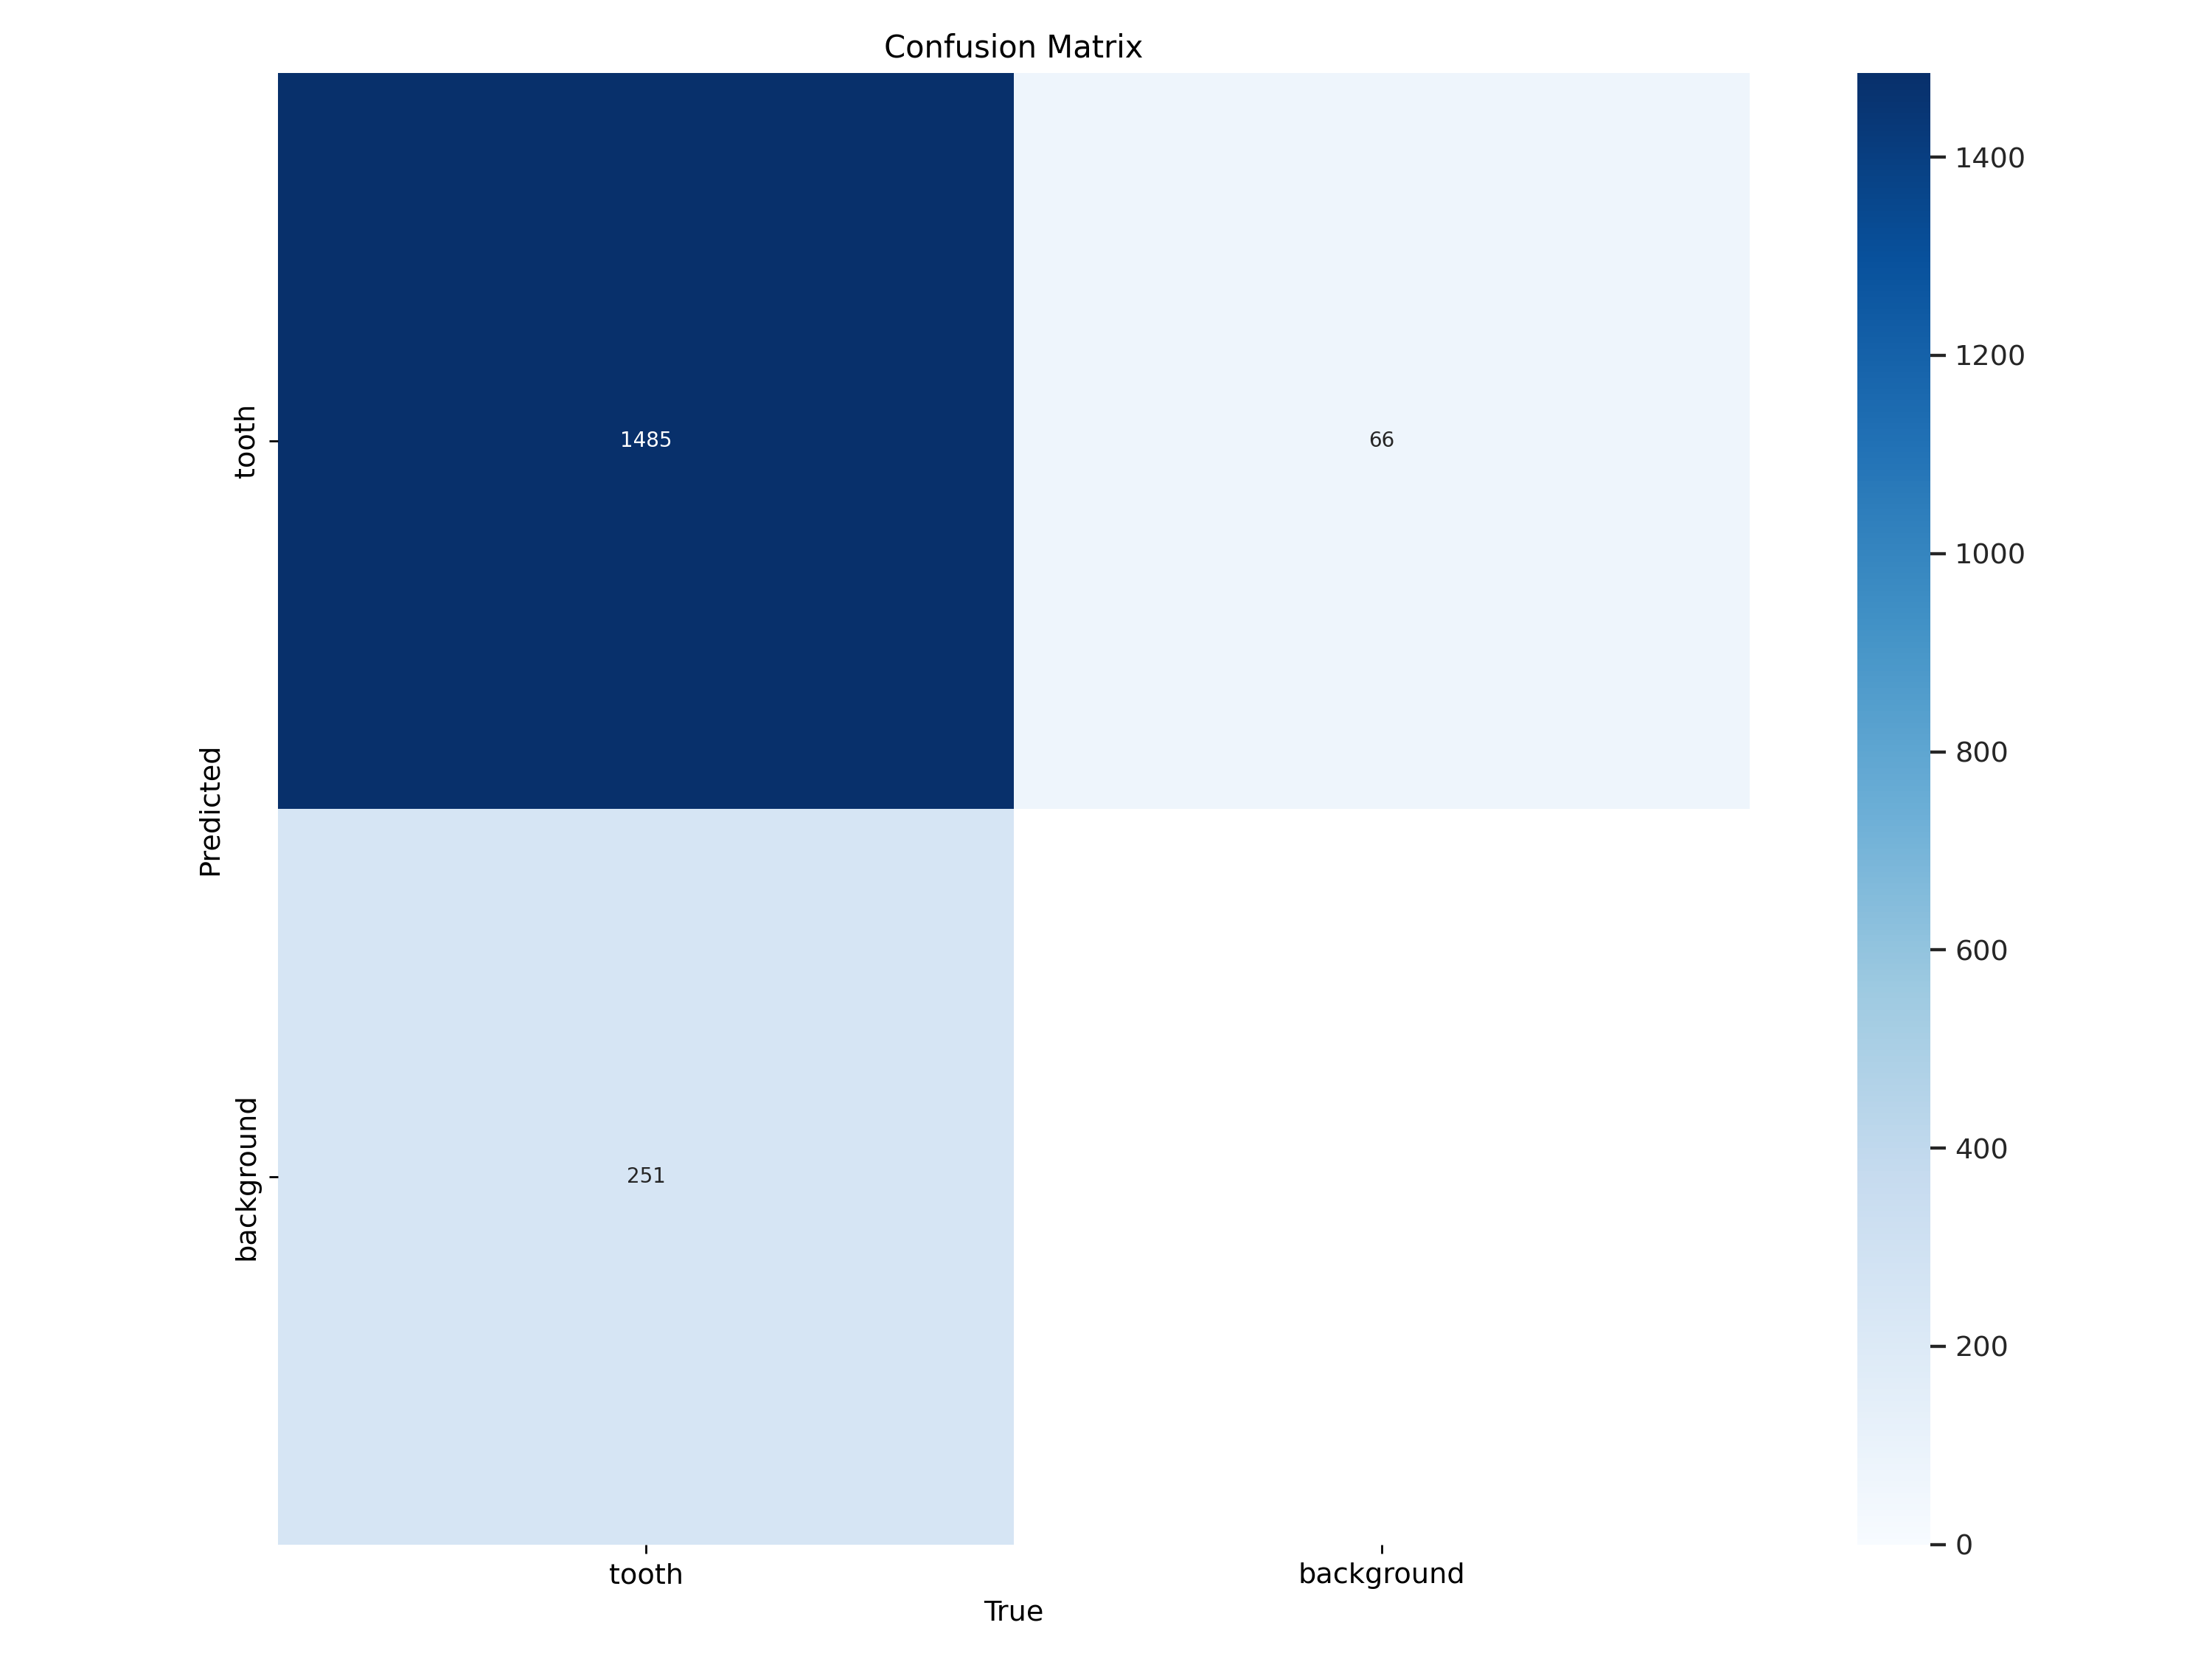

In [ ]:
%cd {HOME}

from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train2/confusion_matrix.png', width=600)

/content


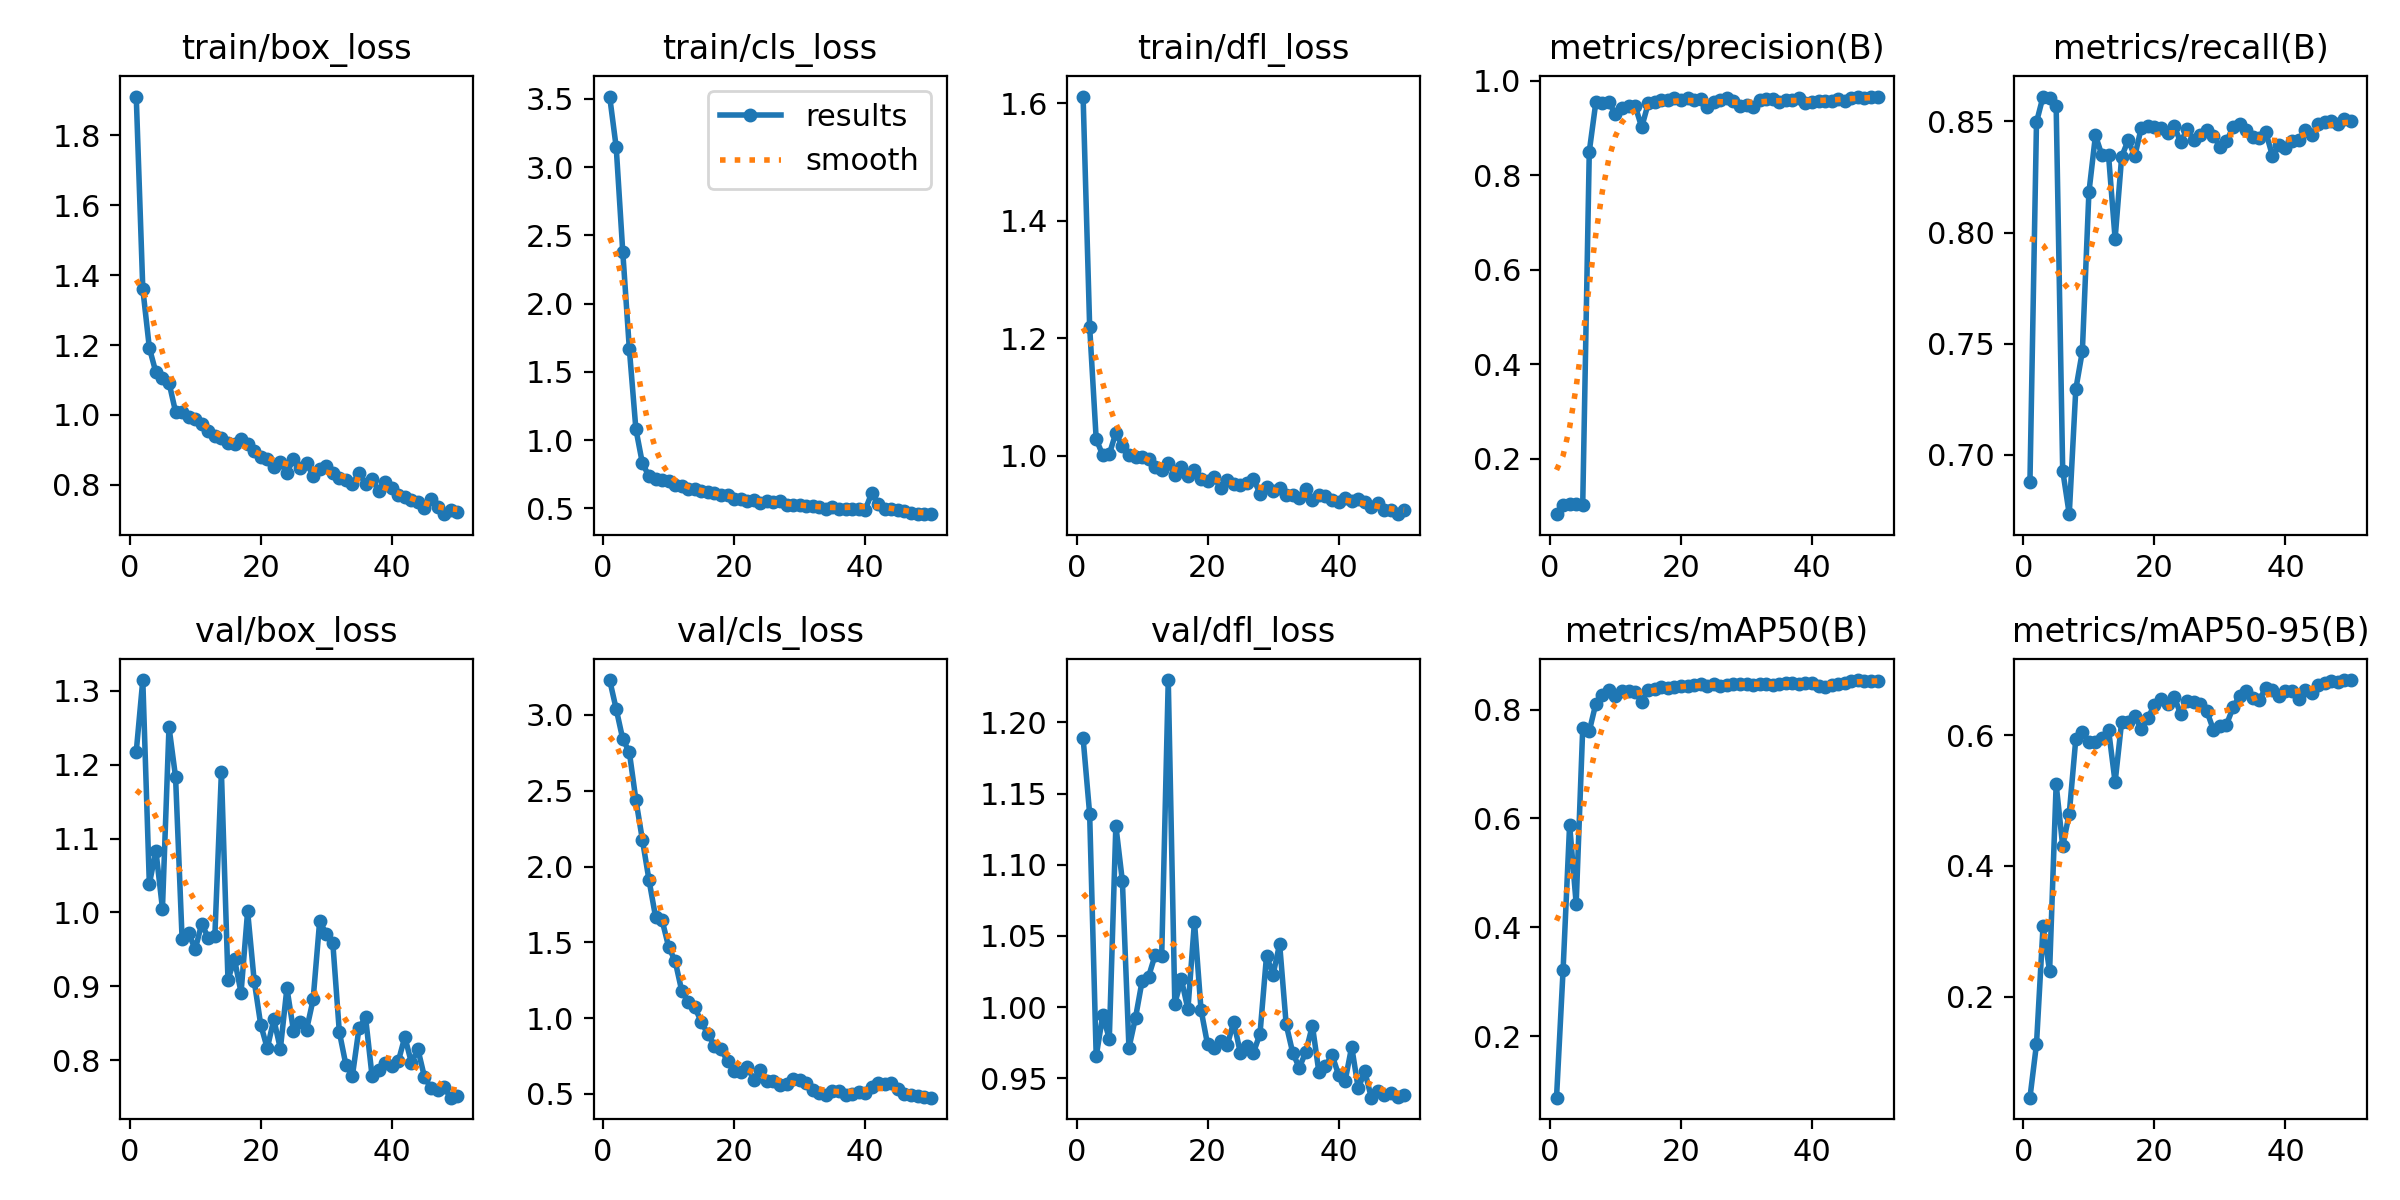

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train2/results.png', width=600)

## Inference with Custom Model

**NOTE:** Let's start by loading our newly trained model.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2;
import matplotlib.pyplot as plt

image = cv2.imread('/content/drive/MyDrive/AI Dentistry - PHD Research/SAM/Testing/Dental-Testing-Images/Categories/category10.jpg')

In [ ]:
!pip install ultralytics

from ultralytics import YOLO
import random

model = YOLO('/content/drive/MyDrive/AI Dentistry - PHD Research/SAM/YOLO MODELS/Tooth/best-segmentation.pt')
results = model(source=image, conf=0.25)


0: 384x640 32 tooths, 9.8ms
Speed: 2.2ms preprocess, 9.8ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)


In [ ]:
results[0].boxes.xyxy

tensor([[ 228.2625,  521.9484,  412.1974,  729.6367],
        [ 348.8337,  571.6487,  538.7407,  783.7485],
        [ 298.8070,  264.4417,  433.2511,  458.5793],
        [ 873.6447,  645.9081,  936.8705,  833.2376],
        [1602.2943,  518.5687, 1775.1567,  729.5580],
        [ 500.6869,  596.6202,  675.3496,  837.6091],
        [1326.9221,  592.1426, 1510.0813,  832.3432],
        [1468.9065,  563.0360, 1655.8040,  791.4431],
        [1086.4764,  366.6998, 1161.8453,  627.1356],
        [1003.3068,  355.8058, 1087.9758,  642.8382],
        [ 765.1860,  296.4042,  854.2968,  613.0822],
        [1399.7612,  336.5500, 1520.7765,  574.5986],
        [1576.4552,  251.3090, 1702.8901,  442.2411],
        [ 375.9041,  317.8096,  493.5804,  553.0089],
        [1509.1262,  321.7992, 1633.2145,  550.4557],
        [ 916.1575,  372.0155, 1001.9714,  641.4334],
        [ 785.7784,  655.4794,  881.0625,  878.9205],
        [1159.2472,  308.3581, 1250.5944,  619.5798],
        [ 841.9725,  366.823


0: 384x640 6 tooths, 11.3ms
Speed: 2.2ms preprocess, 11.3ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


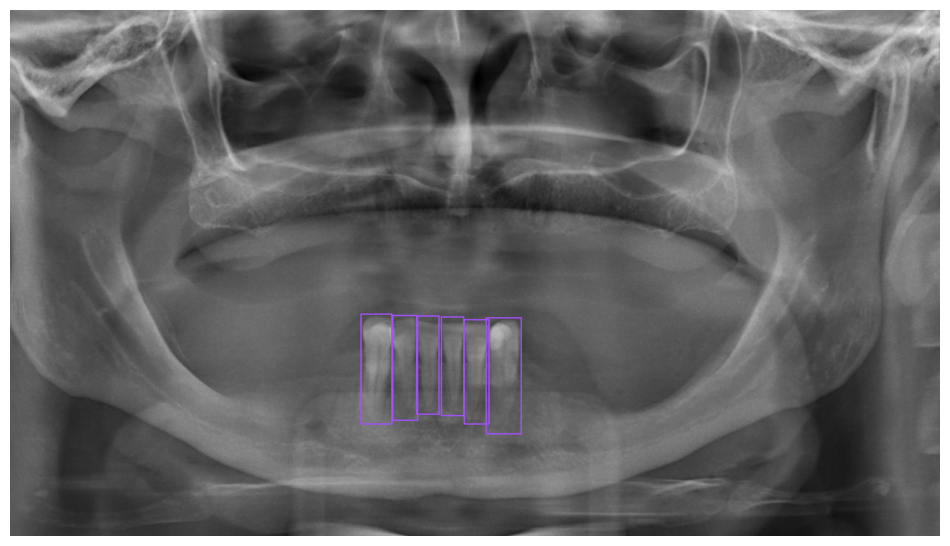

In [ ]:
import cv2
import supervision as sv

model = YOLO('/content/drive/MyDrive/AI Dentistry - PHD Research/SAM/YOLO MODELS/Tooth/best-segmentation.pt')
results = model(image)[0]
detections = sv.Detections.from_ultralytics(results)

bounding_box_annotator = sv.BoundingBoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = bounding_box_annotator.annotate(
    scene=image, detections=detections)

sv.plot_image(annotated_image)

While your deployment is processing, checkout the deployment docs to take your model to most destinations https://docs.roboflow.com/inference